# Feature Analysis

Evidence for what to engineer. Cleaning lives in `preprocessing.ipynb`, training in `scripts/train.py`.

In [15]:
# raw data -- the shared cleaning steps get applied in the next cell
import pandas as pd

df = pd.read_csv("data/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# train-only split, cleaned by the shared pipeline sliced to stop before one-hot
from sklearn.model_selection import train_test_split

from preprocessing import build_preprocessing_pipeline

train_raw, _ = train_test_split(
    df, test_size=0.2, stratify=df["Survived"], random_state=42
)

# no `features` -- EDA wants the raw columns, not the engineered ones built from them
full = build_preprocessing_pipeline()
step_names = [name for name, _ in full.steps]
cleaning = full[: step_names.index("one_hot_encode")]

train = cleaning.fit_transform(train_raw)
train.info()

In [17]:
# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Individual features

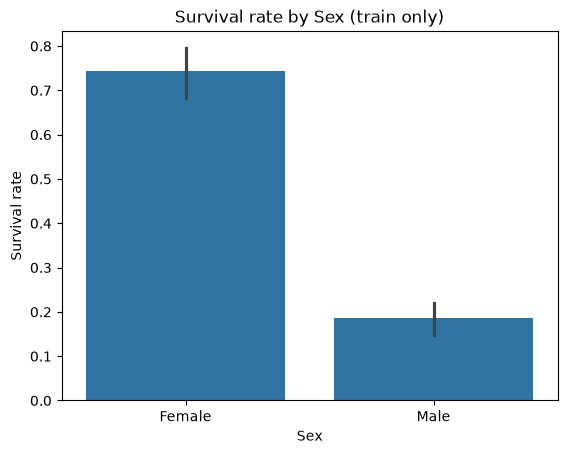

In [18]:
# survival rate by Sex (bar height = mean of the 0/1 Survived column)
sns.barplot(data=train, x="Sex", y="Survived")
plt.xticks([0, 1], ["Female", "Male"])
plt.ylabel("Survival rate")
plt.title("Survival rate by Sex (train only)")
plt.show()

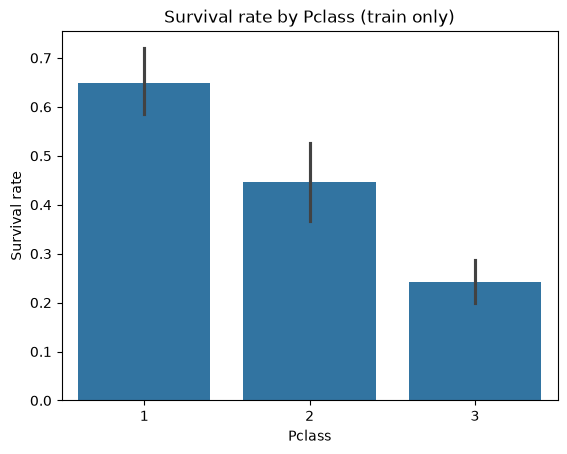

In [19]:
# survival rate by Pclass
sns.barplot(data=train, x="Pclass", y="Survived")
plt.ylabel("Survival rate")
plt.title("Survival rate by Pclass (train only)")
plt.show()

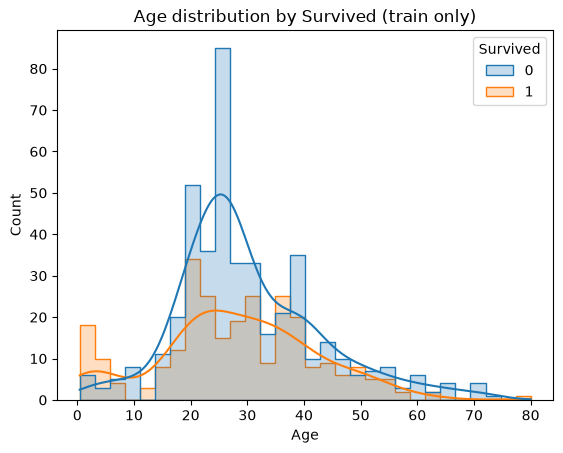

In [20]:
# age distribution, one histogram per Survived group
sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True, element="step")
plt.title("Age distribution by Survived (train only)")
plt.show()

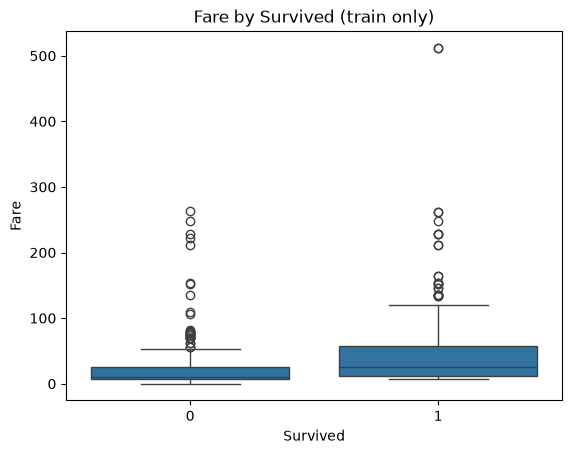

In [21]:
# fare spread and median, compared across Survived
sns.boxplot(data=train, x="Survived", y="Fare")
plt.title("Fare by Survived (train only)")
plt.show()

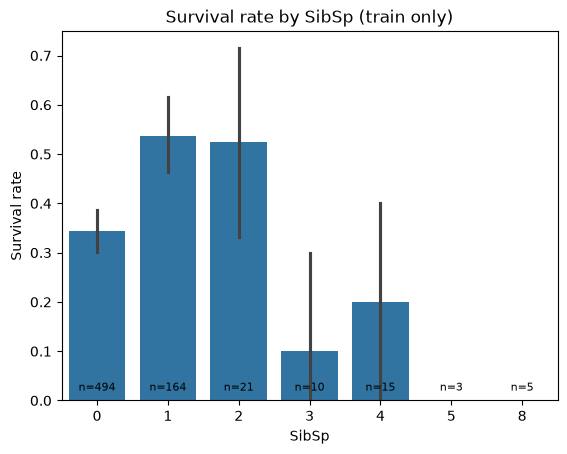

In [22]:
# survival rate by SibSp -- group sizes annotated, the large-family groups are tiny
ax = sns.barplot(data=train, x="SibSp", y="Survived")
for x, n in enumerate(train["SibSp"].value_counts().sort_index()):
    ax.text(x, 0.02, f"n={n}", ha="center", fontsize=8)
plt.ylabel("Survival rate")
plt.title("Survival rate by SibSp (train only)")
plt.show()

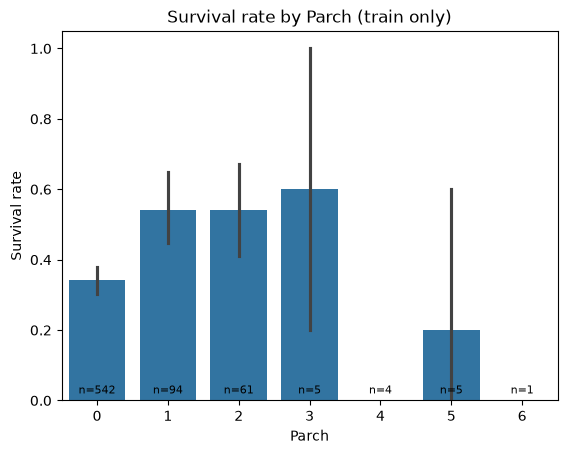

In [23]:
# survival rate by Parch -- same treatment
ax = sns.barplot(data=train, x="Parch", y="Survived")
for x, n in enumerate(train["Parch"].value_counts().sort_index()):
    ax.text(x, 0.02, f"n={n}", ha="center", fontsize=8)
plt.ylabel("Survival rate")
plt.title("Survival rate by Parch (train only)")
plt.show()

## SibSp x Parch interaction

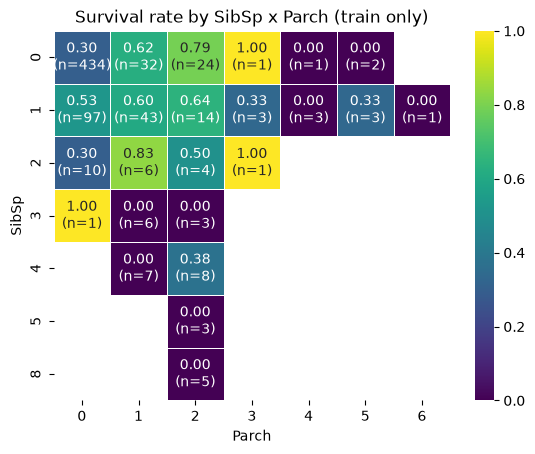

In [ ]:
# joint view -- survival rate per SibSp x Parch cell, blank where nobody falls
rate = train.pivot_table(
    index="SibSp", columns="Parch", values="Survived", aggfunc="mean"
)
counts = train.pivot_table(
    index="SibSp", columns="Parch", values="Survived", aggfunc="size"
)
labels = rate.map(lambda v: "" if pd.isna(v) else f"{v:.2f}") + counts.map(
    lambda n: "" if pd.isna(n) else f"\n(n={int(n)})"
)
sns.heatmap(rate, annot=labels, fmt="", cmap="viridis", vmin=0, vmax=1, linewidths=0.5)
plt.title("Survival rate by SibSp x Parch (train only)")
plt.show()

## Sex x Pclass interaction

In [25]:
# logit with interaction terms -- statsmodels reports the p-values sklearn doesn't
import statsmodels.formula.api as smf

readable = train.assign(
    Sex=train["Sex"].map({0: "Female", 1: "Male"}),
    Pclass=train["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"}),
)
interaction_model = smf.logit("Survived ~ C(Sex) * C(Pclass)", data=readable).fit()
print(interaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.442711
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      706
Method:                           MLE   Df Model:                            5
Date:                Sat, 25 Jul 2026   Pseudo R-squ.:                  0.3350
Time:                        20:02:31   Log-Likelihood:                -315.21
converged:                       True   LL-Null:                       -473.99
Covariance Type:            nonrobust   LLR p-value:                 1.676e-66
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           3.6507      0.716      5.097  

## Cabin

In [12]:
# Cabin is dropped by the cleaning pipeline, so this section works off train_raw.
# 3 in 4 values are missing, so the missingness itself is the first thing to test
cabin = train_raw.assign(
    HasCabin=train_raw["Cabin"].notna().astype(int),
    Deck=train_raw["Cabin"].str[0],
)
print(cabin["HasCabin"].value_counts())

HasCabin
0    552
1    160
Name: count, dtype: int64


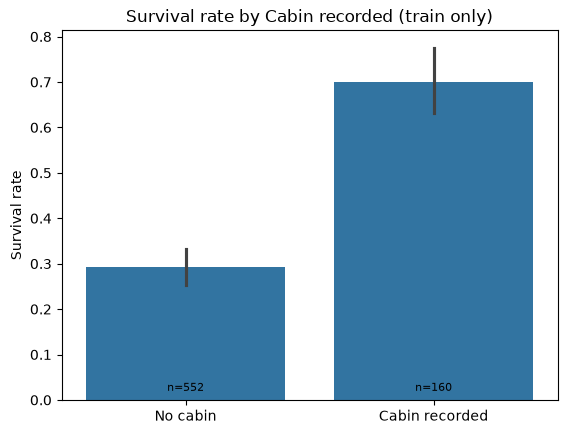

In [13]:
# survival rate by whether a cabin was recorded at all
ax = sns.barplot(data=cabin, x="HasCabin", y="Survived")
for x, n in enumerate(cabin["HasCabin"].value_counts().sort_index()):
    ax.text(x, 0.02, f"n={n}", ha="center", fontsize=8)
plt.xticks([0, 1], ["No cabin", "Cabin recorded"])
plt.xlabel("")
plt.ylabel("Survival rate")
plt.title("Survival rate by Cabin recorded (train only)")
plt.show()

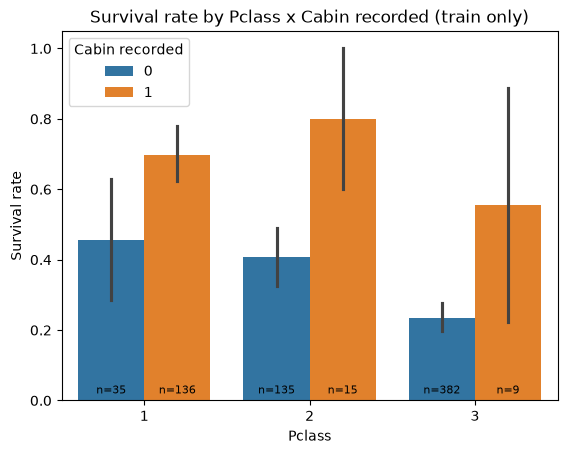

In [14]:
# the same split inside each Pclass -- recorded cabins skew heavily 1st class, so the
# gap above could just be Pclass wearing a different hat. group sizes annotated: the
# recorded-cabin bars in 2nd and 3rd class rest on very few passengers
ax = sns.barplot(data=cabin, x="Pclass", y="Survived", hue="HasCabin")
sizes = cabin.groupby(["Pclass", "HasCabin"]).size()
for bar, (_, n) in zip(
    [b for c in ax.containers for b in c], sizes.sort_index(level=1).items()
):
    ax.text(bar.get_x() + bar.get_width() / 2, 0.02, f"n={n}", ha="center", fontsize=8)
ax.legend(title="Cabin recorded")
plt.ylabel("Survival rate")
plt.title("Survival rate by Pclass x Cabin recorded (train only)")
plt.show()

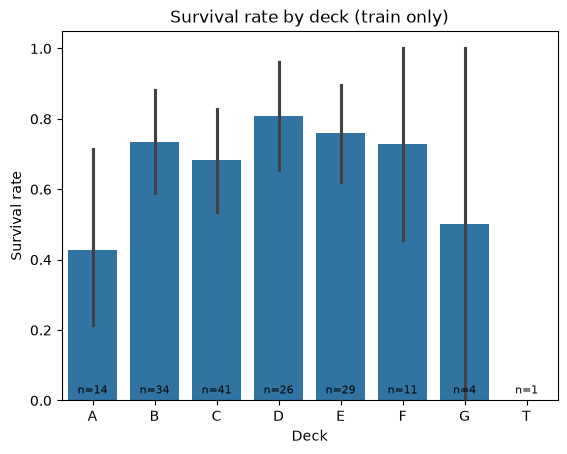

In [15]:
# survival rate by deck letter (first character of Cabin), recorded cabins only
decks = sorted(cabin["Deck"].dropna().unique())
ax = sns.barplot(data=cabin, x="Deck", y="Survived", order=decks)
for x, deck in enumerate(decks):
    ax.text(x, 0.02, f"n={(cabin['Deck'] == deck).sum()}", ha="center", fontsize=8)
plt.ylabel("Survival rate")
plt.title("Survival rate by deck (train only)")
plt.show()

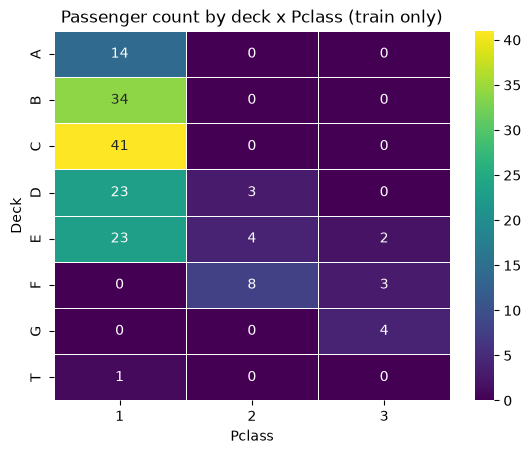

In [16]:
# where the deck cells actually sit -- counts per deck x Pclass, to see how much of the
# deck ordering above is just Pclass and how thin the per-deck samples are
counts = pd.crosstab(cabin["Deck"], cabin["Pclass"])
sns.heatmap(counts, annot=True, fmt="d", cmap="viridis", linewidths=0.5)
plt.title("Passenger count by deck x Pclass (train only)")
plt.show()

In [17]:
# the decisive test: does HasCabin still carry signal once the things it correlates
# with -- Pclass, Sex, Fare -- are controlled for?
cabin_model = smf.logit(
    "Survived ~ HasCabin + C(Pclass) + C(Sex) + Fare", data=cabin
).fit()
print(cabin_model.summary())

Optimization terminated successfully.
         Current function value: 0.451186
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      706
Method:                           MLE   Df Model:                            5
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                  0.3223
Time:                        16:34:58   Log-Likelihood:                -321.24
converged:                       True   LL-Null:                       -473.99
Covariance Type:            nonrobust   LLR p-value:                 6.606e-64
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.2864      0.426      3.019      0.003       0.451       2.121
C(Pclass)[T.2]   

## Conclusions

Both are implemented in `preprocessing.ipynb`:

- **`Male_and_3rdClass`** — the only significant Sex × Pclass interaction (`Male:Pclass=2` was not).
- **One-hot `Pclass`** — the effect isn't linear (1st ≈ 2nd, cliff at 3rd), so 1/2/3 would assume even spacing.